In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
from dmri.simulators.global_signal_models.curves3d import sample_splines, VoxelGrid, get_average_tangent_in_voxels, get_spline_volume_fraction_in_voxels
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

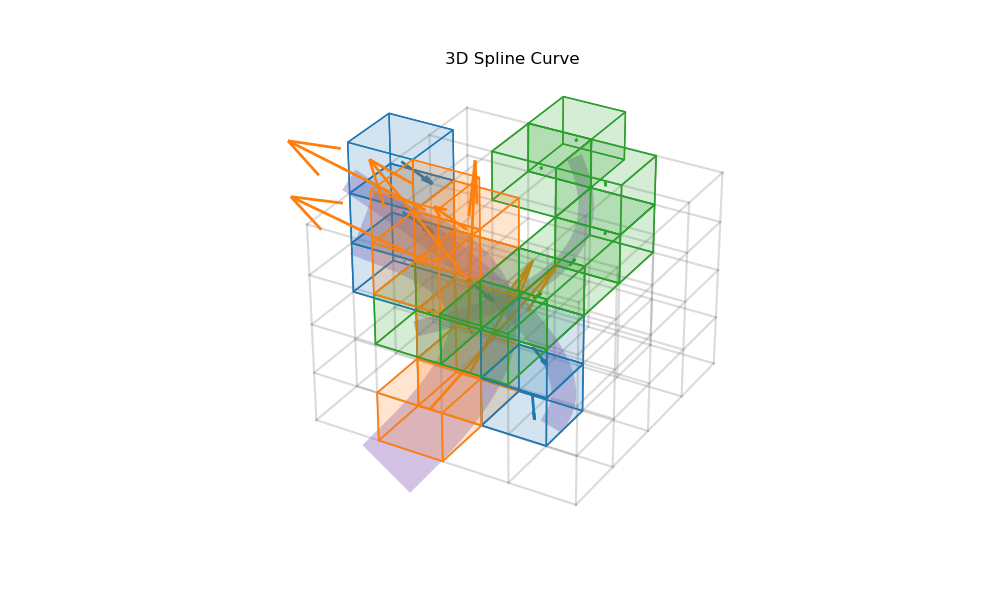

In [10]:
%matplotlib widget

from itertools import combinations, product
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
grid = VoxelGrid(4,4,4)
ax.grid(False)

grid_lines_x, grid_lines_y, grid_lines_z = grid.get_grid_lines()


start = 13
for i in range(3):
    diameter = jax.random.uniform(jax.random.key(start +100 + i), shape=(), minval=0.05, maxval=0.4)
    spline = sample_splines(jax.random.key(start + i), degree=2)
    t_line = jnp.linspace(0, 1, 100)
    spline_values = spline(t_line)
    voxel_idxs = jax.vmap(grid.get_voxel_index_for_point)(spline_values)
    voxel_idxs = jnp.unique(voxel_idxs, axis=0)

    average_tangets = get_average_tangent_in_voxels(spline, grid)
    volume_fraction = get_spline_volume_fraction_in_voxels(spline, grid,diameter)


    for voxel_idx in voxel_idxs:
        voxel_start, voxel_end = grid.get_voxel_boundaries(*voxel_idx)
        # Create a list of vertices for the 3D box
        vertices = [
            [voxel_start[0], voxel_start[1], voxel_start[2]],
            [voxel_start[0], voxel_start[1], voxel_end[2]],
            [voxel_start[0], voxel_end[1], voxel_start[2]],
            [voxel_start[0], voxel_end[1], voxel_end[2]],
            [voxel_end[0], voxel_start[1], voxel_start[2]],
            [voxel_end[0], voxel_start[1], voxel_end[2]],
            [voxel_end[0], voxel_end[1], voxel_start[2]],
            [voxel_end[0], voxel_end[1], voxel_end[2]]
        ]

        # Create a list of sides for the 3D box
        sides = [[vertices[j] for j in [0, 1, 3, 2]],
                 [vertices[j] for j in [4, 5, 7, 6]],
                 [vertices[j] for j in [0, 1, 5, 4]],
                 [vertices[j] for j in [2, 3, 7, 6]],
                 [vertices[j] for j in [0, 2, 6, 4]],
                 [vertices[j] for j in [1, 3, 7, 5]]]

        # Add the 3D box to the plot
        ax.add_collection3d(Poly3DCollection(sides, facecolors=f'C{i}', linewidths=1, edgecolors=f'C{i}', alpha=.1))

    # Plot the average tangent vectors
    for voxel_idx in voxel_idxs:
        avg_tangent = average_tangets[tuple(voxel_idx)]
        center = jnp.array(grid.get_voxel_center(*voxel_idx))
        volume = volume_fraction[tuple(voxel_idx)]
        norm = jnp.linalg.norm(avg_tangent)
        if norm > 0:
            # Calculate the endpoint to maintain the direction
            direction = avg_tangent / norm #* 0.25  # Normalize the tangent

            ax.quiver(center[0], center[1], center[2], direction[0],direction[1],direction[2], color=f'C{i}', length=volume, lw=2)

    # Plot the grid lines
    for i in range(grid_lines_x.shape[0]):
        for j in range(grid_lines_x.shape[1]):
            ax.plot(grid_lines_x[i, j, :], grid_lines_y[i, j, :], grid_lines_z[i, j, :], color='gray', alpha=0.1)
            ax.plot(grid_lines_x[i, :, j], grid_lines_y[i, :, j], grid_lines_z[i, :, j], color='gray', alpha=0.1)
            ax.plot(grid_lines_x[:, i, j], grid_lines_y[:, i, j], grid_lines_z[:, i, j], color='gray', alpha=0.1)


    # Plot the spline values
    ax.plot(spline_values[:, 0], spline_values[:, 1], spline_values[:, 2], lw=diameter*200, alpha=0.4, color=f'C{i}')


    # Set labels and show plot
    # ax.set_xlabel("X-axis")
    # ax.set_ylabel("Y-axis")
    # ax.set_zlabel("Z-axis")
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.set_title("3D Spline Curve")

plt.show()

In [15]:
start = 1
i = 0
grid = VoxelGrid(4,4,4)
diameter = jax.random.uniform(jax.random.key(start +100 + i), shape=(), minval=0.05, maxval=0.4)
spline = sample_splines(jax.random.key(start + i), degree=1)
t_line = jnp.linspace(0, 1, 100)
spline_values = spline(t_line)


voxel_idxs = jax.vmap(grid.get_voxel_index_for_point)(spline_values)
voxel_idxs = jnp.unique(voxel_idxs, axis=0)
average_tangets = get_average_tangent_in_voxels(spline, grid)
volume_fraction = get_spline_volume_fraction_in_voxels(spline, grid,diameter)

# Volumes

In [30]:
from dmri.simulators.global_signal_models.fiber_prior import FiberPrior

fiber_prior = FiberPrior(4,3)

def f(key):
    num_samples = jax.random.randint(key, shape=(), minval=1, maxval=10)
    return [fiber_prior.sample(k) for k in jax.random.split(key, num_samples)]

jax.jit(f)(jax.random.PRNGKey(0))

TypeError: Shapes must be 1D sequences of concrete values of integer type, got (Traced<ShapedArray(int32[])>with<DynamicJaxprTrace>,).
If using `jit`, try using `static_argnums` or applying `jit` to smaller subfunctions.
The error occurred while tracing the function f at /tmp/ipykernel_6693/4053608674.py:5 for jit. This concrete value was not available in Python because it depends on the value of the argument key.

In [44]:
dirichlet_samples = jax.random.dirichlet(jax.random.PRNGKey(0), jnp.array([2., 1.1]), shape=(1000, ))

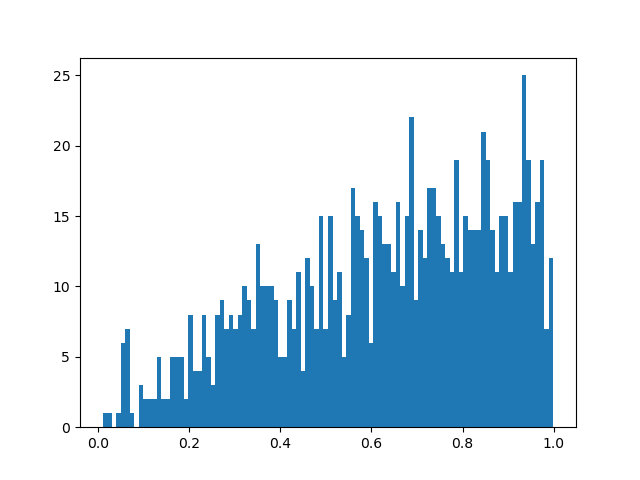

In [45]:
fig = plt.figure()
plt.hist(dirichlet_samples[:, 0], bins=100)
plt.show()